## MSML602 Final Tutorial: AI Generated vs. Human Written Content
#### Ronoy Sarkar

### Data Curation, Parsing, and Management

For this tutorial the data we are using is the AI vs Human Comparison Dataset. This dataset provides some text samples that were either written by humanas or generated by AI models, as well as some metadata behind the samples. This data can be used to identify differences between the two, evaluate the effectiveness of AI for text generation, compare the performance of different AI sources, and possible train a model to differentiate between human and AI sourced content.

This is an important dataset to view because there are many instances where people ought to be able to distinguish between AI and human generated content, especially as AI models become more advanced and the distinctions between the two seem to become smaller. Developing a model to do this could be scaled for real-world use cases. To do this exploration, I will be following the data science pipeline 


The first step in the data science pipeline is getting the data and ensuring it is organized and usable for the future steps. The data can be downloaded from https://www.kaggle.com/datasets/prince7489/ai-vs-human-comparison-dataset?resource=download. 


Once it is downloaded as a .csv file, it should be placed in the same working directory as the jupyter notebook. The first thing to do is to store the file as a pandas dataframe which can be done using the following code:

In [387]:
import pandas as pd
df = pd.read_csv('data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                500 non-null    int64  
 1   label             500 non-null    object 
 2   topic             500 non-null    object 
 3   text              500 non-null    object 
 4   length_chars      500 non-null    int64  
 5   length_words      500 non-null    int64  
 6   quality_score     500 non-null    float64
 7   sentiment         500 non-null    float64
 8   source_detail     500 non-null    object 
 9   timestamp         500 non-null    object 
 10  plagiarism_score  500 non-null    float64
 11  notes             157 non-null    object 
dtypes: float64(3), int64(3), object(6)
memory usage: 47.0+ KB


The next part of the process is data preprocessing, where we make the data usable. This info function immediately gives us information about the columns in the dataset, known as features, as well as their type and number of entries. We immediately see that the notes feature contains only 157 entries, which is less than the others. We can determine from viewing the dataset that notes contains non-essential information so in this case it can simply be dropped. This can be done using the code below.

In [388]:
df = df.drop(columns=['notes'])
df.head()

,id,label,topic,text,length_chars,length_words,quality_score,sentiment,source_detail,timestamp,plagiarism_score
0,305,human,food,"As someone who follows food, I believe privacy...",126,22,2.37,0.44,author_50,2023-12-19 11:21:46,0.045
1,341,ai,travel,Analysis indicates that travel is associated w...,141,19,3.44,0.60,gpt-5-base,2024-04-01 17:43:26,0.007
2,48,human,education,I recently experienced education in my day-to-...,112,17,3.16,-0.43,author_33,2025-08-28 07:56:09,0.163
3,68,ai,sports,Analysis indicates that sports is associated w...,101,14,3.32,0.44,claude-2,2023-10-23 14:34:48,0.122
4,480,human,finance,"In my experience, finance often leads to users...",78,14,3.52,-0.31,author_87,2024-11-28 11:31:37,0.105


Now, we used the head to notice that column was dropped entirely. Another thing that stands out here is that the timestamp column contains a datetime structure that describes when each data point was created. One change we may want to make is to simply add a new column to store only the portion of the timestamp that we actually need, ignoring the exact HH:MM:SS portion.

In [389]:
df['time'] = pd.to_datetime(df['timestamp']).dt.date
df = df.drop(columns=['timestamp'])
df.head()

,id,label,topic,text,length_chars,length_words,quality_score,sentiment,source_detail,plagiarism_score,time
0,305,human,food,"As someone who follows food, I believe privacy...",126,22,2.37,0.44,author_50,0.045,2023-12-19
1,341,ai,travel,Analysis indicates that travel is associated w...,141,19,3.44,0.60,gpt-5-base,0.007,2024-04-01
2,48,human,education,I recently experienced education in my day-to-...,112,17,3.16,-0.43,author_33,0.163,2025-08-28
3,68,ai,sports,Analysis indicates that sports is associated w...,101,14,3.32,0.44,claude-2,0.122,2023-10-23
4,480,human,finance,"In my experience, finance often leads to users...",78,14,3.52,-0.31,author_87,0.105,2024-11-28


Now that we have mostly removed the unnecessary information, we can examine the data more closely. Source_detail stands out because it has values that look like they might repeat. Using value_counts we can see what values are represented.

In [390]:
df['source_detail'].value_counts()

claude-2         61
bloomz-7b        51
gpt-5-base       50
gpt-4o-mini      46
llama-3-small    43
                 ..
author_2          1
author_77         1
author_13         1
author_38         1
author_60         1
Name: source_detail, Length: 95, dtype: int64

Here we see that there are some AI models which have high counts as well as some human ones denoted by author_[INT]. If we want to create a binary method to distinguish between human and AI we can just replace the label column with 0 for human and 1 for ai 

In [391]:
df['label'] = df['label'].replace({'human': 0, 'ai': 1})
df.head()

,id,label,topic,text,length_chars,length_words,quality_score,sentiment,source_detail,plagiarism_score,time
0,305,0,food,"As someone who follows food, I believe privacy...",126,22,2.37,0.44,author_50,0.045,2023-12-19
1,341,1,travel,Analysis indicates that travel is associated w...,141,19,3.44,0.60,gpt-5-base,0.007,2024-04-01
2,48,0,education,I recently experienced education in my day-to-...,112,17,3.16,-0.43,author_33,0.163,2025-08-28
3,68,1,sports,Analysis indicates that sports is associated w...,101,14,3.32,0.44,claude-2,0.122,2023-10-23
4,480,0,finance,"In my experience, finance often leads to users...",78,14,3.52,-0.31,author_87,0.105,2024-11-28


Now let's understand what each column represents:

- ID is just the identifier used
- Label is a 0 for human generated and 1 for AI
- Topic covers what the text is about
- Text is the generated sample
- Length_chars is the number of characters in the sample
- Length_words is the number of words
- Quality_score measures the overall quality
- Sentiment measures the positive or negative sentiment
- Source_detail is who wrote it (note human authors are anonymized)
- The plagiarism score determines how plagiarized text seems
- Time stores when the sample was generated

The next step is Exploratory Data Analysis, where we can look for trends or patterns in the data that we can explore further.

### Exploratory Data Analysis

A good starting point is to use a heatmap which shows the correlation between different numeric features. Using the library seaborn helps create good visualizations for this

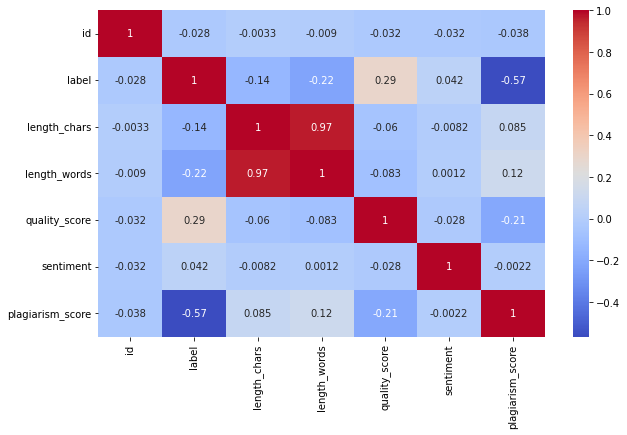

In [392]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

This is interesting. We notice a strong positive correlation between length_words and length_chars which is to be expected. We also notice a medium negative correlation between plagiarism_score and label which indicates they may be somewhat correlated. Next we can create a plot to examine whether different AI models perform differently. First, we may want to understand how many there are. 

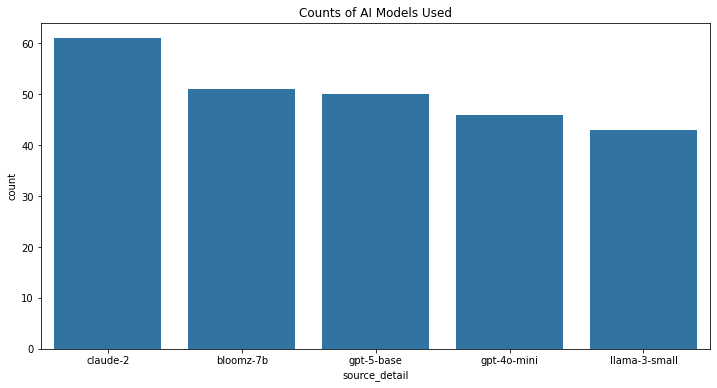

In [393]:
author_df = df[df['label'] == 1] # only look at AI generated ones
plt.figure(figsize=(12,6))
sns.countplot(data=author_df, x='source_detail', order=author_df['source_detail'].value_counts().index)
plt.title('Counts of AI Models Used')
plt.show()

Above, we can see claude-2 has the most data entries and llama-3-small has the least. Next, we can try to look at the quality score based on whether it was human or AI made.

Text(0.5, 1.0, 'Quality Score for Human vs AI Text Generation')

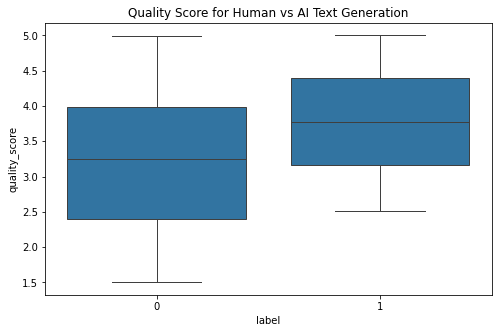

In [394]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='quality_score', data=df)
plt.title('Quality Score for Human vs AI Text Generation')

Here we can tell that the distributions both seem fairly uniform but that AI has a higher median quality score and also a smaller variance and range. Next lets look at distributions for both in an easier format using kde.

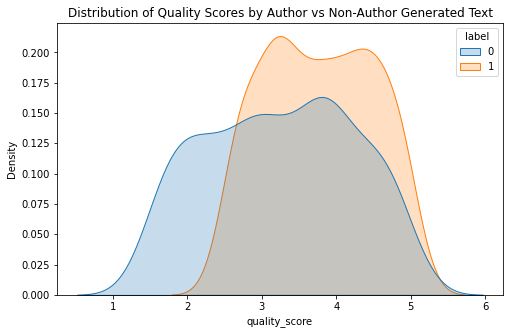

In [395]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='quality_score', hue='label', fill=True)
plt.title('Distribution of Quality Scores by Author vs Non-Author Generated Text')
plt.show()

This helps us more clearly see the previous distributions visually. It seems fairly normally distributed for both although the AI generated content is bimodal with two peaks around 3 and 5. They are still uniform however, and the human generated text quality has higher variability as we noted before. Next lets see if the topic category affects the quality. For this I will elect to use a violin plot as it makes comparing across many different categories easier.

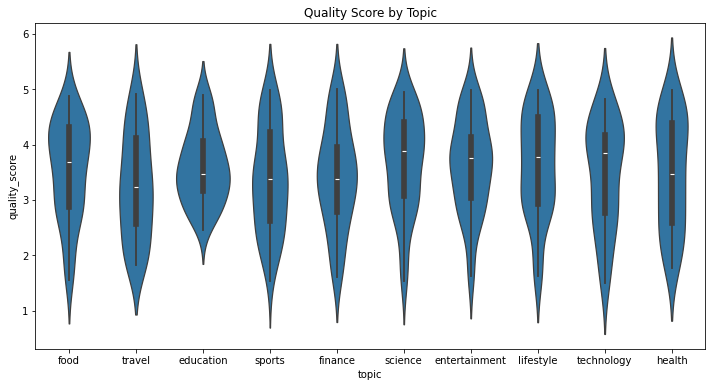

In [396]:
plt.figure(figsize=(12,6))
sns.violinplot(x='topic', y='quality_score', data=df)
plt.title('Quality Score by Topic')
plt.show()

This shows us mostly normal distributions although some categories, like education, have a narrower range. The medians are also all roughly between 3 and 4. They also all appear unimodal with the possible exception of lifestyle and sports

Now we can look at the average scores by category between the two types of text generation. A joint bar plot is ideal for this because we can see the relationship of categories together as well as differences between human and AI side by side

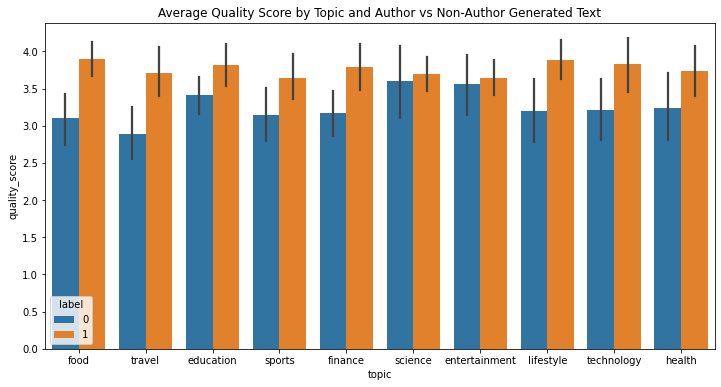

In [397]:
plt.figure(figsize=(12,6))
sns.barplot(x='topic', y='quality_score', hue='label', data=df)
plt.title('Average Quality Score by Topic and Author vs Non-Author Generated Text')
plt.show()

Here we notice that the AI generated content always has higher average quality than the human generated content. However, some appear closer than others. It may help to calculate out the differences by subtracting the averages and then ranking them to see which ones have the least disparity.

In [398]:
topic_quality = df.groupby(['topic', 'label'])['quality_score'].mean().unstack() # calculate means
topic_quality['difference'] = topic_quality[1] - topic_quality[0] # subtract to find differences
ranked_topics = topic_quality.sort_values(by='difference') # sort ascending
print(ranked_topics[['difference']]) # print

label          difference
topic                    
entertainment    0.087333
science          0.094389
education        0.404762
sports           0.493587
health           0.509457
finance          0.612674
technology       0.617750
lifestyle        0.687545
food             0.803871
travel           0.830758


Here we can clearly see that entertainment and science are notably lower in terms of difference between the two, which is visible from looking at the graph. The highest disparity is in trabel. Next lets see how sentiment relates to the content generation.

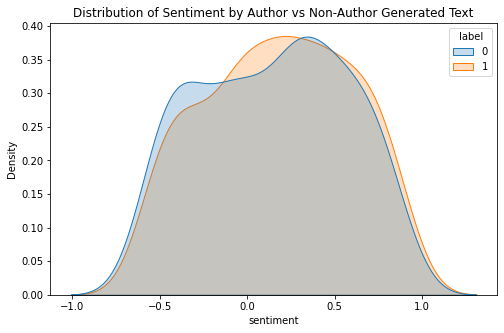

In [399]:
# create a kde plot of sentiment based on label
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='sentiment', hue='label', fill=True)
plt.title('Distribution of Sentiment by Author vs Non-Author Generated Text')
plt.show()

This plot shows a relatively normal distribution for AI generated, showing it may be more predictable in terms of sentiment. It is also centered fairly close to zero showing not much bias. Human generated content seems bimodal although still centered around zero. The variability of both is comparable. Next let's examine the relationship between length and quality of text

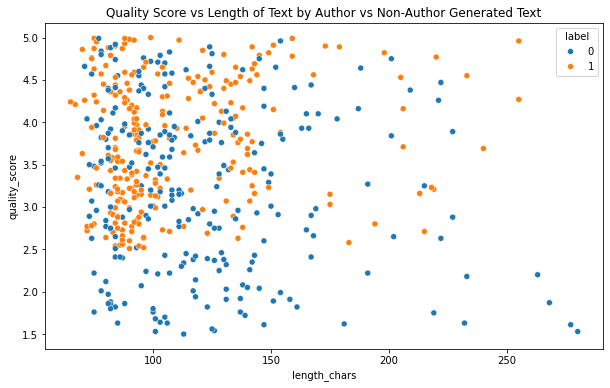

In [400]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='length_chars', y='quality_score', hue='label')
plt.title('Quality Score vs Length of Text by Author vs Non-Author Generated Text')
plt.show()

This plot shows the data doesn't have much of a pattern. It can be noticed there are more entries with length less than 150 than more as the points are more densely connected in this region. AI generated content also seems to have higher quality, as we noted previously. We can create a similar graphi for plagiarism.

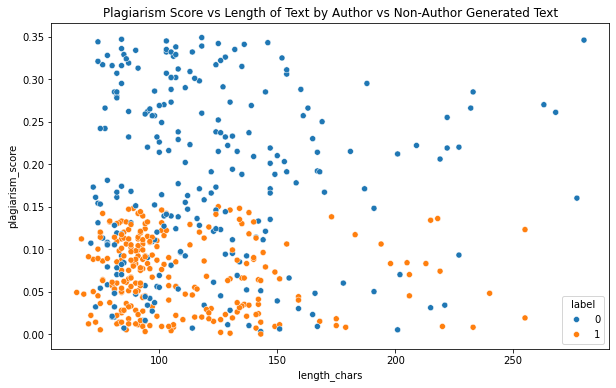

In [401]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='length_chars', y='plagiarism_score', hue='label')
plt.title('Plagiarism Score vs Length of Text by Author vs Non-Author Generated Text')
plt.show()

This gives a very clear indicator of lower plagiarism scores for AI generated content, ironically. Now it makes sense to also understand the time component of this. In other words, is quality changing over time as models improve? We can compare this side by side using a joint box plot.

/var/folders/kn/vym1b70j5xb3yf5r_496s2s40000gp/T/ipykernel_20466/2466476813.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  author_df['year'] = author_df['time'].apply(lambda x: x.year) # get year from column


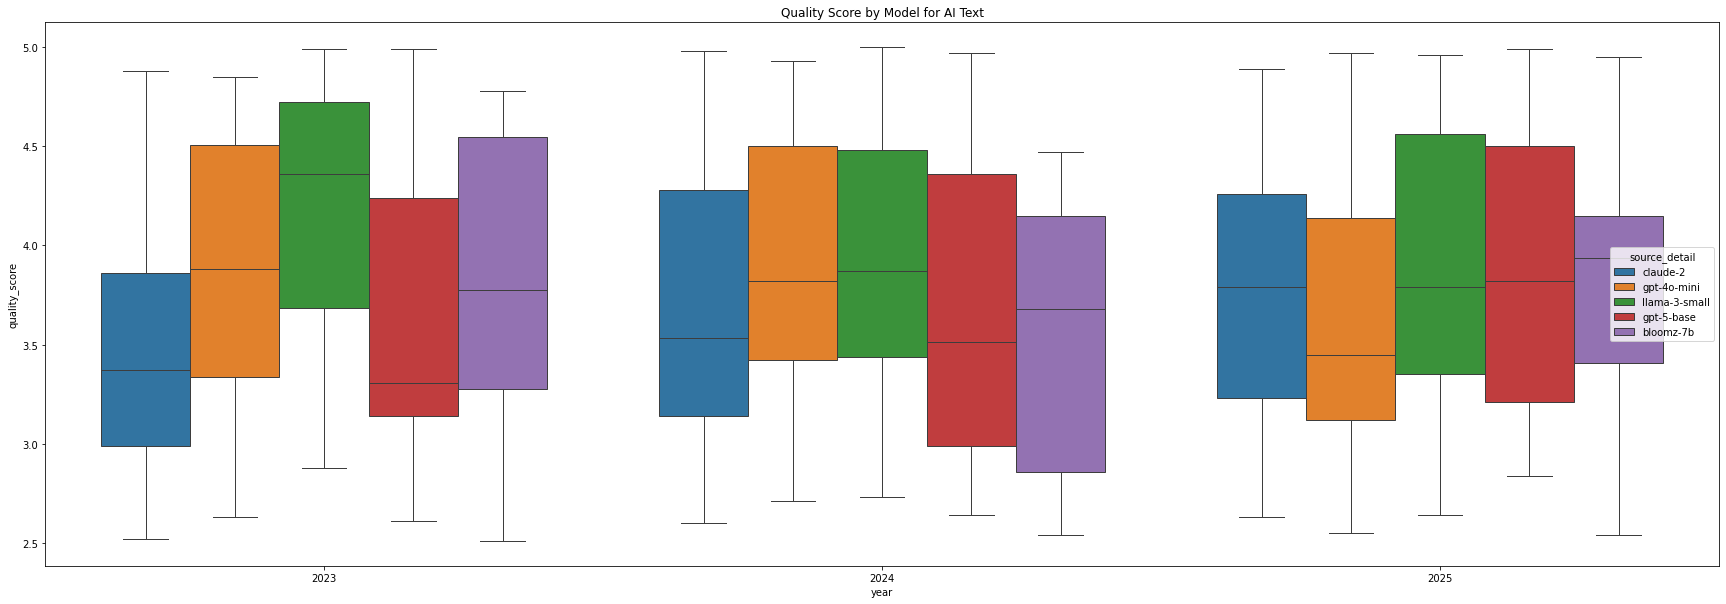

In [402]:
author_df = df[df['label'] == 1]
author_df['year'] = author_df['time'].apply(lambda x: x.year) # get year from column

plt.figure(figsize=(30,10))
sns.boxplot(data=author_df, x='year', y='quality_score', hue='source_detail')
plt.title('Quality Score by Model for AI Text')
plt.show()

This gives us a lot of insight. The biggest trend seems to be that the models appear to perform closer together over time as the boxes representing the middle 50% of data get closer together and the ranges also seem closer. There is no relation amon which model performs the best as it changes over time, although llama-3-small appears to be amongt the top performers throughout. Let's see if a lineplot makes it easier to compare the trends.

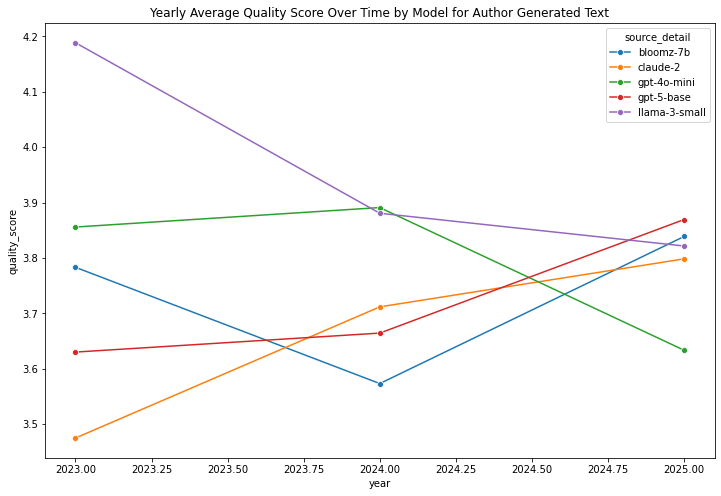

In [403]:
# recreate the above chart as a line plot with yearly averages instead of box plot
yearly_avg = author_df.groupby(['year', 'source_detail'])['quality_score'].mean().reset_index()
plt.figure(figsize=(12,8))
sns.lineplot(data=yearly_avg, x='year', y='quality_score', hue='source_detail', marker='o')
plt.title('Yearly Average Quality Score Over Time by Model for Author Generated Text')
plt.show()

This is much easier to tell but it looks like llama-3 generally was high for most of it although now gpt-5 has improved the most over time. Next let's look closer at how plagiarism is affected by human vs AI generation

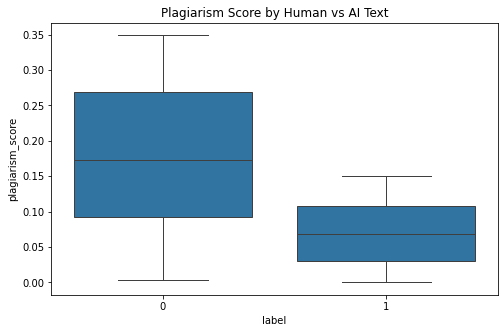

In [404]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='plagiarism_score', data=df)
plt.title('Plagiarism Score by Human vs AI Text')
plt.show()

This shows a huge disparity between the two. The average plagiarism score is higher for humans which much higher variability. All of the the AI generated scores are below the median human generated score.

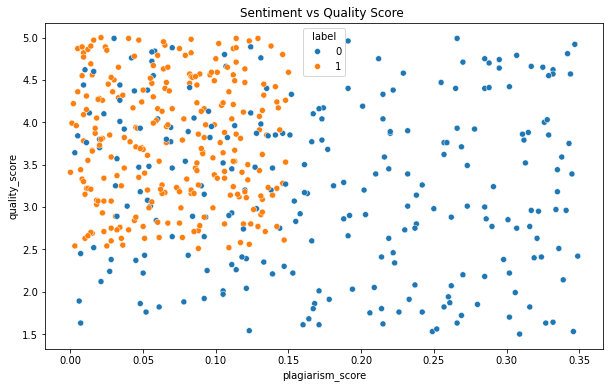

In [405]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='plagiarism_score', y='quality_score', hue='label')
plt.title('Sentiment vs Quality Score ')
plt.show()

Now we can see the lower plagiarism scores for AI generated content but also that there is little relation with quality scores. The human data also seems completely randomly distributed regarding both, showing no relation.

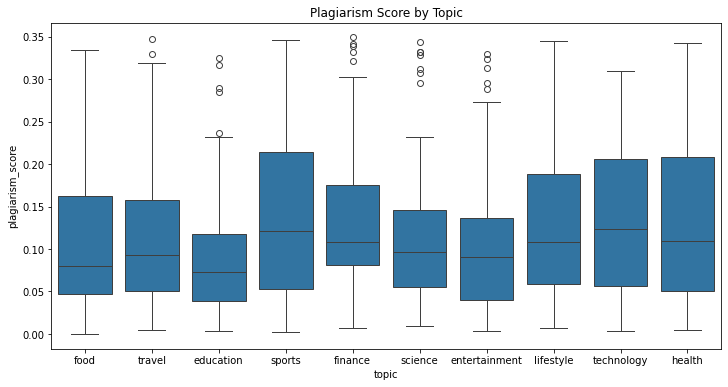

In [406]:
plt.figure(figsize=(12,6))
sns.boxplot(x='topic', y='plagiarism_score', data=df)
plt.title('Plagiarism Score by Topic')
plt.show()

Lastly I created boxplots to see the distributions of plagiarism across each topic. There was a lot of disparity and many notable outliers in some categories. Next, we can look towards trying to build a model that can help use some of the insights gathered to create something that is applicable in the real world.

### Model Building + Optimization

The intuition here is to build a model to predict whether something is human or AI based on the associated metadata. There are a few obvious considerations to make:
1) We need to drop source_detail, and label columns since that gives away whether it is human or AI
2) We want to only use the metadata meaning considering the text turns this into a sentiment analysis problem which means it should also be dropped
3) We want to use Group Shuffle to allow us to test performance on each group separately to prevent learning on other factors

We use the sklearn library to help with all this.

We begin by importing the necessary libraries, splitting into X and y set and setting up a group shuffle to develop test/train sets

In [407]:
# Imports
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split by groups
groups = df["source_detail"]

# Drop other columns
X = df.drop(columns=["label", "source_detail", "text", "topic"])
y = df["label"]

# Store numeric columns 
numeric_cols = [
    "length_chars",
    "length_words",
    "quality_score",
    "sentiment",
    "plagiarism_score"
]

# Split and get test data
temp = GroupShuffleSplit(test_size=0.2)
train_idx, test_idx = next(temp.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

Now that we have test/train, we can use Pipeline to effectively preprocess and run our model. I chose a LogisticRegression Model which performs regression and is a good baseline model to help predict and gauge the accuracy on this task.

In [408]:
pipeline = Pipeline([
    ("preprocess", ColumnTransformer([
        ("num", "passthrough", numeric_cols)
    ])),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    ))
])

pipeline.fit(X_train, y_train)
print(accuracy_score(y_test, pipeline.predict(X_test)))


0.75


We notice that the accuracy score given is around 0.75 which is acceptable but not as high as we would want. There are a few optimizations that might make sense to improve upon this.

1) Using Group K-fold cross validation. More about this can be explained at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html
2) Using GridSearch to find optimized parameters for the model. This is explained at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
3) Scaling numbers using a StandardScaler(). This can be learned about from: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html


In [409]:
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Building the pipeline
pipeline = Pipeline([
    ("preprocess", ColumnTransformer([
        ("num", StandardScaler(), numeric_cols) # Scaling columns
    ])),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    ))
])

# Setting up grid search
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

# Performing grid search
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=GroupKFold(n_splits=10),
    scoring="accuracy",
    n_jobs=-1
)


grid.fit(X, y, groups=groups)
print(grid.best_score_)


0.7991464077434253


The best score we get from this is slightly higher at around 0.8 which shows the optimizations did help improve the model. However, it may be a limitation of the model itself that we can't improve more. Instead we can try a different model, such as a RandomForestClassifier. You can read more about this at https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html.

We use a similar setup to the previous model and use 5-fold group cross validation. 

In [410]:
from sklearn.ensemble import RandomForestClassifier

pipeline2 = Pipeline([
    ("preprocess", ColumnTransformer([
        ("num", "passthrough", numeric_cols)
    ])),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced"
    ))
])

scores = cross_val_score(
    pipeline2,
    X,
    y,
    groups=groups,
    cv=GroupKFold(n_splits=5),
    scoring="accuracy",
    n_jobs=-1
)

print(scores.mean())


0.842


Here we received an improved accuracy which shows that this model is outperforming even the optimal logistic regression. When evaluating or optimizing a model it is also often helpful to look at metrics beyond accuracy such as recall rate or precision. 
This site gives a great explanation on how to understand the metrics behind a model performance: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/

The final step within the pipeline is to create real-world recommendations or conclusions.

### Conclusion

We were able to follow the data science pipeline to first import the data and ensure that we removed unncessary information. We then set about creating new columns and making it provide useful information for our exploration. During the exploratory data analysis portion we calculated metrics and visualized relationships within the data to help us understand it better. Then we trained two models: an optimized logistic regression model and a random forest classifier to try and compare their performances. While very high accuracy was not achieved, we could in the future try more models as well as more optimization methods within the dataset. We were still able to build a model to relatively accurately distinguish between human and AI generated text based solely on metadata. This is applicable to the real-world as it could be used to help differentiate between the two and could be trained using newer developed metrics for text analysis. Thank you for reading the tutorial and make sure to look at the links for more information!